<a href="https://colab.research.google.com/github/opherdonchin/BayesShortCourse/blob/main/sleep/solved/11_exgaussian_flat_priors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sleep deprivation 11 — Flat common-effect priors

Repeat notebook 9's ex-Gaussian model, but make the common-effect priors improper and flat, while keeping the same hierarchical priors for the participant-level terms.

## Setup

This course pins PyMC and the modular ArviZ packages for reproducibility because their APIs can change across major versions.

In [1]:
%pip install -q \
    "pandas==2.2.3" \
    "pymc==6.3.2" \
    "arviz-base==1.3.0" \
    "arviz-stats==1.3.2" \
    "arviz-plots[matplotlib]==1.3.1"

Note: you may need to restart the kernel to use updated packages.


D:\Repositories\BayesShortCourse\tmp\colabenv\Scripts\python.exe: No module named pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import pymc as pm
import arviz_base as azb
import arviz_plots as azp
import arviz_stats as azs

RANDOM_SEED = 20260924
azp.style.use("arviz-variat")

print("PyMC:", pm.__version__)
print("arviz-base:", azb.__version__)
print("arviz-plots:", azp.__version__)
print("arviz-stats:", azs.__version__)

g++ not available, if using conda: `conda install gxx`


PyMC: 6.3.2
arviz-base: 1.3.0
arviz-plots: 1.3.1
arviz-stats: 1.3.2


## Data

The original study contains two adaptation/training days followed by a baseline measurement and then seven nights of severe sleep restriction. You can read about the original study here: [Belenky J Sleep Res. 2003](https://doi.org/10.1046/j.1365-2869.2003.00337.x)

Following the chapter, we drop original days 0–1 and subtract 2 from the remaining day number. Therefore **`Days = 0` is the baseline measurement before sleep deprivation begins**.

That zero point is scientifically meaningful, so every model in this sequence keeps `Days` on its natural scale (no centering). The intercept prior is therefore a prior on baseline reaction time rather than reaction time at the average deprivation day.

In [3]:
DATA_URL = "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/lme4/sleepstudy.csv"

sleep = pd.read_csv(DATA_URL).drop(columns="rownames")
sleep = sleep.loc[sleep["Days"] >= 2].copy()
sleep["Days"] = sleep["Days"] - 2
sleep["Subject"] = sleep["Subject"].astype(str)
sleep = sleep.reset_index(drop=True)

print(f"{sleep['Subject'].nunique()} participants, {len(sleep)} observations")
print(f"Days: {sleep['Days'].min()} to {sleep['Days'].max()}")
sleep.head()

18 participants, 144 observations
Days: 0 to 7


,Reaction,Days,Subject
0,250.8006,0,308
1,321.4398,1,308
2,356.8519,2,308
3,414.6901,3,308
4,382.2038,4,308


### Plotting helpers

These helper functions draw the regression and its uncertainties. There are two: one for showing population regressions and one for showing individual regressions.

#### Format colors

In [4]:
# orange mean line, blue 50% and 90% HDI bands, black observed points.
LM_VISUALS = {
    "pe_line": {"color": "C1"},
    "ci_band": {"color": "C0"},
    "observed_scatter": {"color": "black", "alpha": 1, "zorder": 3, "s": 10},
}
PARTICIPANT_DAY = xr.Coordinates.from_pandas_multiindex(
    pd.MultiIndex.from_frame(sleep[["Subject", "Days"]], names=["participant", "day"]),
    "obs_id",
)

#### plot_population

Plot any variable against days using plot_lm. Use the standard colors and legend above.

In [5]:

def plot_population(dt, var, group="posterior"):
    """Single-panel trend of `var` against days, with all 144 raw observations."""
    pc = azp.plot_lm(
        dt,
        x="days",
        y=var,
        y_obs="Reaction",
        group=group,
        plot_dim="obs_id",
        ci_prob=(0.50, 0.90),
        ci_kind="hdi",
        point_estimate="mean",
        smooth=False,
        figure_kwargs={"figsize": (7, 4)},
        visuals={
            **LM_VISUALS,
            "xlabel": False,
            "ylabel": False,
        },
    )

    pc.facet_map("labelled_x", text="Days of sleep deprivation")
    pc.facet_map("labelled_y", text="Reaction time (ms)")
    pc.add_legend("prob", title="HDI")

    return pc

#### plot_participants

The same as plot_population but for the participants. 

In [6]:
def plot_participants(dt, group, var):
    """One panel per participant: bands for `var` against days, with that participant's data."""
    def reshape(ds):
        return ds.assign_coords(PARTICIPANT_DAY).unstack("obs_id")

    panels = xr.DataTree.from_dict({
        group: reshape(dt[group].to_dataset()),
        "observed_data": reshape(dt["observed_data"].to_dataset()),
        "constant_data": reshape(dt["constant_data"].to_dataset()),
    })

    pc = azp.plot_lm(
        panels,
        x="days",
        y=var,
        y_obs="Reaction",
        group=group,
        plot_dim="day",
        ci_prob=(0.50, 0.90),
        ci_kind="hdi",
        point_estimate="mean",
        smooth=False,
        cols=["participant"],
        col_wrap=6,
        figure_kwargs={"figsize": (11, 5.5), "sharex": True, "sharey": True},
        visuals={**LM_VISUALS, "xlabel": False, "ylabel": False},
    )

    pc.add_legend("prob", title="HDI")

    fig = pc.get_viz("figure")
    fig.supxlabel("Days of sleep deprivation")
    fig.supylabel("Reaction time (ms)")

    return pc

In [7]:
participants = sorted(sleep["Subject"].unique(), key=int)
participant_idx = sleep["Subject"].map({p: i for i, p in enumerate(participants)}).to_numpy()

## 11.1 Removing prior information

What information is removed when the common ex-Gaussian priors are made flat?

The book removes most default priors while retaining hierarchical priors for varying coefficients. We express the same experiment by giving the common-effect parameters (`intercept`, `slope`, `sigma_intercept`, `nu_intercept`) improper flat priors, while leaving the participant-level hierarchical priors exactly as in notebook 9. These are intentionally poor priors for a teaching comparison, not a recommendation.

In [8]:
coords = {"obs_id": np.arange(len(sleep)), "participant": participants}

with pm.Model(coords=coords) as model:
    days = pm.Data("days", sleep["Days"].to_numpy(), dims="obs_id")
    pidx = pm.Data("participant_idx", participant_idx, dims="obs_id")

    intercept = pm.Flat("intercept")
    slope = pm.Flat("slope")

    participant_intercept_sd = pm.Exponential("participant_intercept_sd", lam=0.04)
    participant_intercept_z = pm.Normal("participant_intercept_z", 0, 1, dims="participant")
    participant_intercept = pm.Deterministic(
        "participant_intercept",
        participant_intercept_sd * participant_intercept_z,
        dims="participant",
    )

    participant_slope_sd = pm.Exponential("participant_slope_sd", lam=0.10)
    participant_slope_z = pm.Normal("participant_slope_z", 0, 1, dims="participant")
    participant_slope = pm.Deterministic(
        "participant_slope",
        participant_slope_sd * participant_slope_z,
        dims="participant",
    )

    sigma_intercept = pm.Flat("sigma_intercept")
    participant_sigma_sd = pm.Exponential("participant_sigma_sd", lam=3)
    participant_sigma_z = pm.Normal("participant_sigma_z", 0, 1, dims="participant")
    participant_sigma = pm.Deterministic(
        "participant_sigma",
        participant_sigma_sd * participant_sigma_z,
        dims="participant",
    )
    residual_scale = pm.Deterministic(
        "residual_scale",
        pm.math.exp(sigma_intercept + participant_sigma),
        dims="participant",
    )

    nu_intercept = pm.Flat("nu_intercept")
    tail = pm.Deterministic("tail", pm.math.exp(nu_intercept))

    population_mu = pm.Deterministic(
        "population_mu", intercept + slope * days, dims="obs_id"
    )
    mu = pm.Deterministic(
        "mu",
        population_mu
        + participant_intercept[pidx]
        + participant_slope[pidx] * days,
        dims="obs_id",
    )
    sigma = pm.Deterministic("sigma", residual_scale[pidx], dims="obs_id")

    mean_rt = pm.Deterministic("mean_rt", mu + tail, dims="obs_id")
    population_mean_rt = pm.Deterministic(
        "population_mean_rt", population_mu + tail, dims="obs_id"
    )

    pm.ExGaussian(
        "Reaction",
        mu=mu,
        sigma=sigma,
        nu=tail,
        observed=sleep["Reaction"].to_numpy(),
        dims="obs_id",
    )

Improper flat priors do not define a proper prior predictive distribution, so unlike the preceding notebooks there is **no prior predictive check** here. That absence is itself part of the lesson.

## 11.2 Computational stability

Can this flexible hierarchical ex-Gaussian model still be sampled reliably with improper flat priors?

In [9]:
with model:
    idata = pm.sample(
        draws=1000, tune=2500, chains=4, target_accept=0.97, random_seed=RANDOM_SEED
    )

print("Divergences:", int(idata["sample_stats"]["diverging"].sum().item()))
azs.summary(idata, var_names=["intercept", "slope", "participant_intercept_sd", "participant_slope_sd", "sigma_intercept", "participant_sigma_sd", "nu_intercept"], ci_prob=0.90, ci_kind="hdi", round_to=2)

Initializing NUTS using jitter+adapt_diag...


D:\Repositories\BayesShortCourse\tmp\colabenv\Lib\site-packages\pytensor\tensor\rewriting\elemwise.py:1004: UserWarning: Loop fusion failed because the resulting node would exceed the kernel argument limit.
  warn(


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [intercept, slope, participant_intercept_sd, participant_intercept_z, participant_slope_sd, participant_slope_z, sigma_intercept, participant_sigma_sd, participant_sigma_z, nu_intercept]


D:\Repositories\BayesShortCourse\tmp\colabenv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

...

Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Divergences: 2033


,mean,sd,hdi90_lb,hdi90_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
intercept,267.32,8.86,252.09,280.45,387.51,599.58,1.01,0.45,0.28
slope,11.65,2.05,8.21,14.86,491.12,746.86,1.01,0.09,0.05
participant_intercept_sd,34.96,6.86,24.64,45.34,531.40,642.18,1.01,0.31,0.28
participant_slope_sd,7.58,1.56,5.29,10.16,595.24,867.27,1.00,0.06,0.05
sigma_intercept,2.82,0.17,2.53,3.08,540.13,754.62,1.00,0.01,0.00
participant_sigma_sd,0.63,0.13,0.42,0.83,808.42,901.22,1.00,0.00,0.00
nu_intercept,-181.77,107.41,-332.85,-0.30,511.13,521.72,1.01,4.42,1.46


## 11.3 Reading a failed fit

What would we wrongly conclude if we ignored the diagnostics?

Shown only to illustrate; with this many divergences these plots are not evidence. Each panel shows posterior uncertainty in that participant's expected reaction time.

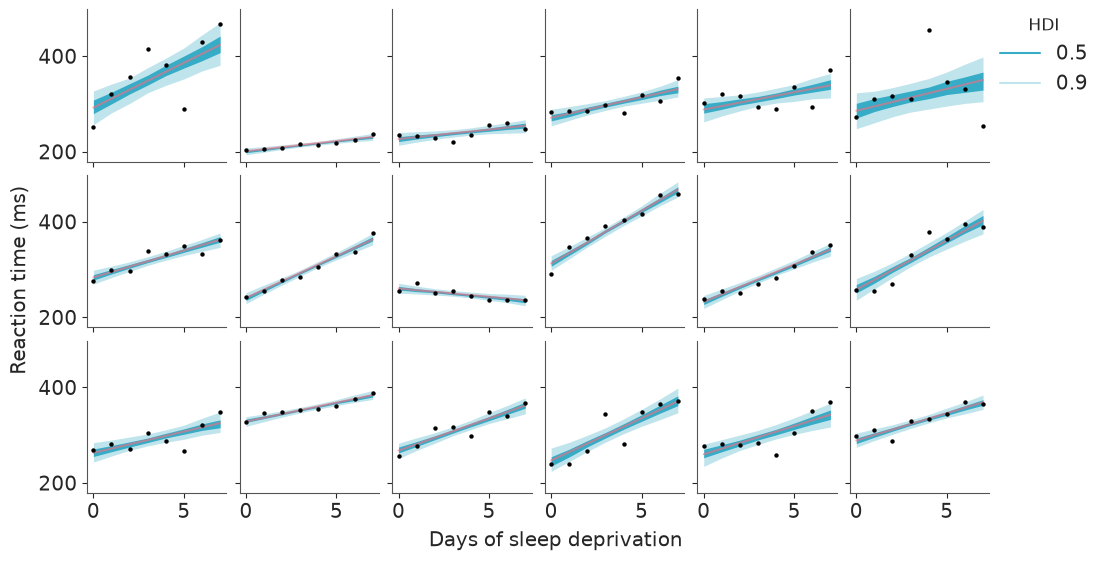

In [10]:
plot_participants(idata, "posterior", "mean_rt")
plt.show()

Sampling: [Reaction]


D:\Repositories\BayesShortCourse\tmp\colabenv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

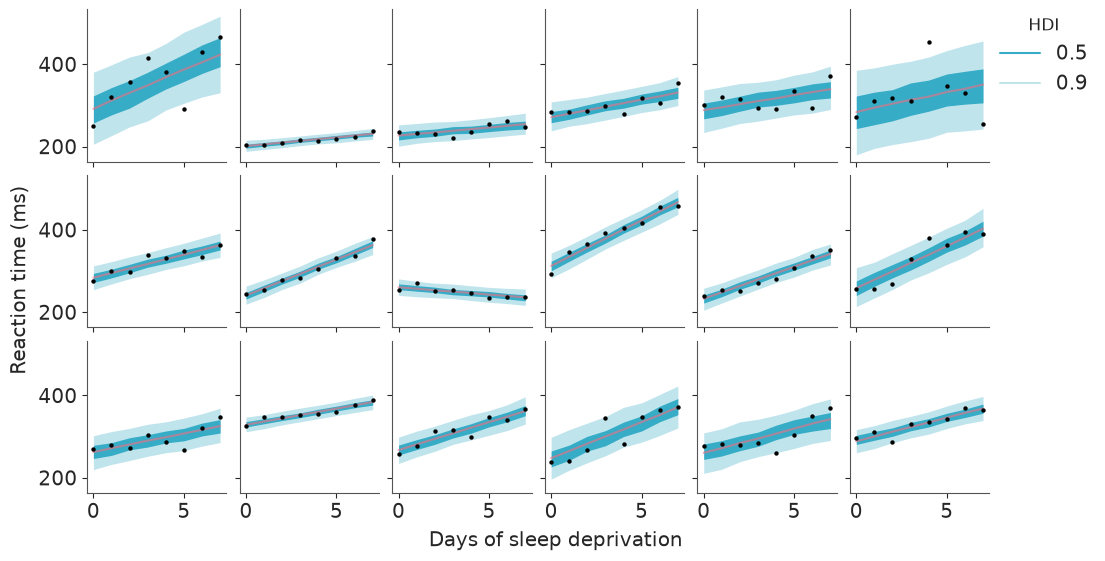

In [11]:
with model:
    pm.sample_posterior_predictive(
        idata, var_names=["Reaction"], extend_inferencedata=True, random_seed=RANDOM_SEED
    )

plot_participants(idata, "posterior_predictive", "Reaction")
plt.show()

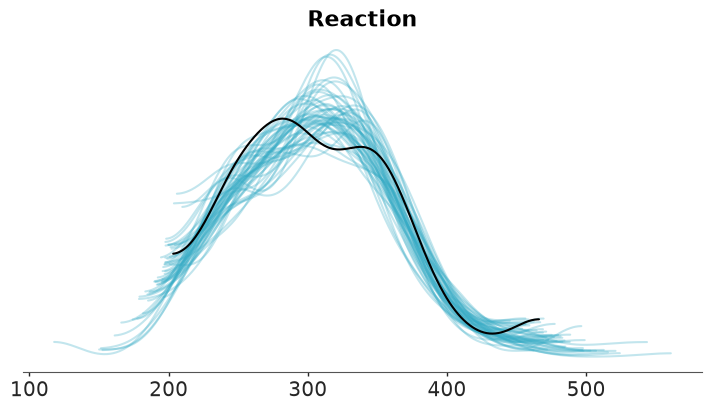

In [12]:
azp.plot_ppc_dist(idata, var_names=["Reaction"], kind="kde", figure_kwargs={"figsize": (7, 4)});

## 11.4 Weak identification

Where does weak identification become visible when prior regularization is removed?

The fit produced 2033 divergences out of 4000 draws, R-hat up to 1.01, and bulk ESS as low as ~390 — the sampler was genuinely struggling, not merely slow. The population intercept and slope still landed close to notebook 9's values, but `nu_intercept` came back essentially unidentified (mean about $-182$ on the log scale, SD over 100): the flat prior gives the data almost nothing to anchor the tail against, and the posterior wanders across an enormous range of near-zero exponential tails. The point is not that flat priors must fail, but that a flexible hierarchical distributional model can contain directions — here, the tail parameter — that are only weakly informed by these data. Diagnostics and scientifically meaningful prior information become more important as model flexibility increases.